In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/ai4i2020.csv")

# Remove identifier columns
df = df.drop(columns=["UDI", "Product ID"])

# Remove failure indicators to avoid leakage
df = df.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])

# Separate features and target
X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

# Encode Type
X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (8000, 7)
X_test: (2000, 7)


In [3]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [4]:
class_weight="balanced"

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8245
Precision: 0.14177215189873418
Recall   : 0.8235294117647058
F1 Score : 0.24190064794816415
ROC-AUC  : 0.906954085982219

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



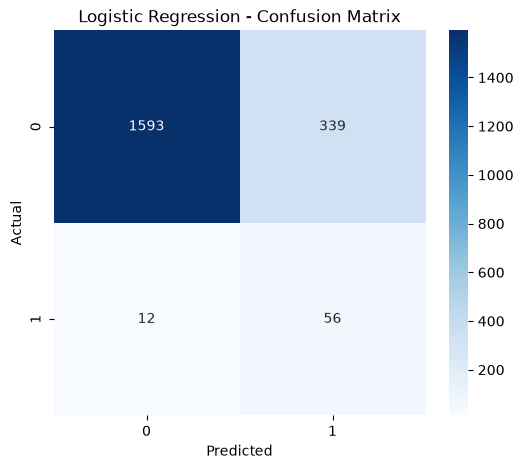

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [7]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [8]:
print("Decision Tree Results")
print("---------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 0.9295
Precision: 0.31088082901554404
Recall   : 0.8823529411764706
F1 Score : 0.45977011494252873
ROC-AUC  : 0.9079474180976739

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.31      0.88      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.91      0.71      2000
weighted avg       0.97      0.93      0.95      2000



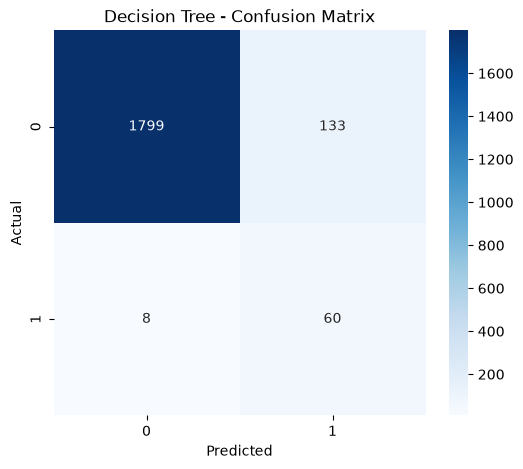

In [9]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [11]:
print("Random Forest Results")
print("--------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
--------------------
Accuracy : 0.982
Precision: 0.75
Recall   : 0.7058823529411765
F1 Score : 0.7272727272727273
ROC-AUC  : 0.963867068566557

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.71      0.73        68

    accuracy                           0.98      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.98      0.98      0.98      2000



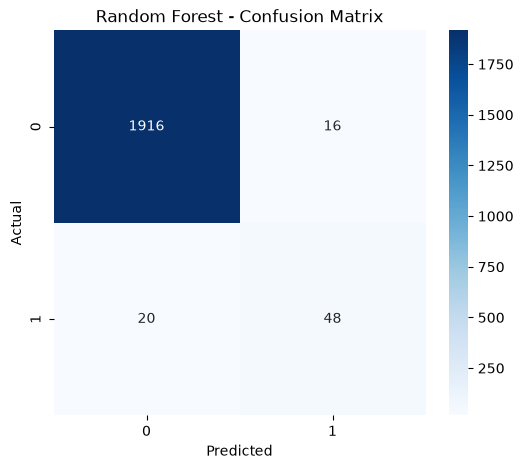

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
print(X_train.dtypes)

Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Type_L                        bool
Type_M                        bool
dtype: object


In [15]:
print(X_train.dtypes[X_train.dtypes == "object"])

Series([], dtype: object)


In [17]:
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = (
    X_train_xgb.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

X_test_xgb.columns = X_train_xgb.columns

print(X_train_xgb.columns.tolist())

['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_L', 'Type_M']


In [18]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train)

y_pred_xgb = xgb_model.predict(X_test_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

In [19]:
print("XGBoost Results")
print("----------------")

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
----------------
Accuracy : 0.9865
Precision: 0.9183673469387755
Recall   : 0.6617647058823529
F1 Score : 0.7692307692307693
ROC-AUC  : 0.9721714772865668

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.92      0.66      0.77        68

    accuracy                           0.99      2000
   macro avg       0.95      0.83      0.88      2000
weighted avg       0.99      0.99      0.99      2000



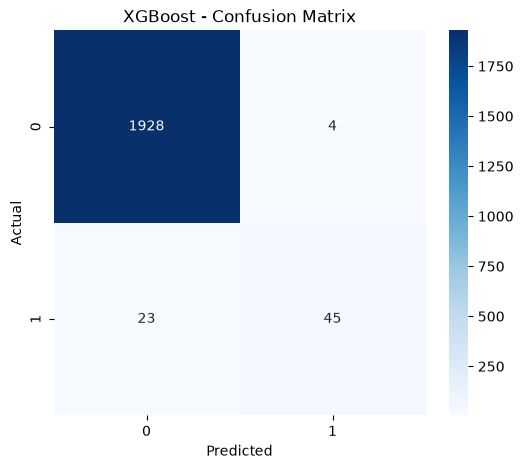

In [20]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1": f1_score(y_test, y_pred_lr),
        "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
    },

    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1": f1_score(y_test, y_pred_dt),
        "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
    },

    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    },

    "XGBoost": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb),
        "Recall": recall_score(y_test, y_pred_xgb),
        "F1": f1_score(y_test, y_pred_xgb),
        "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
    }
}

results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8245,0.141772,0.823529,0.241901,0.906954
Decision Tree,0.9295,0.310881,0.882353,0.459770,0.907947
Random Forest,0.9820,0.750000,0.705882,0.727273,0.963867
XGBoost,0.9865,0.918367,0.661765,0.769231,0.972171


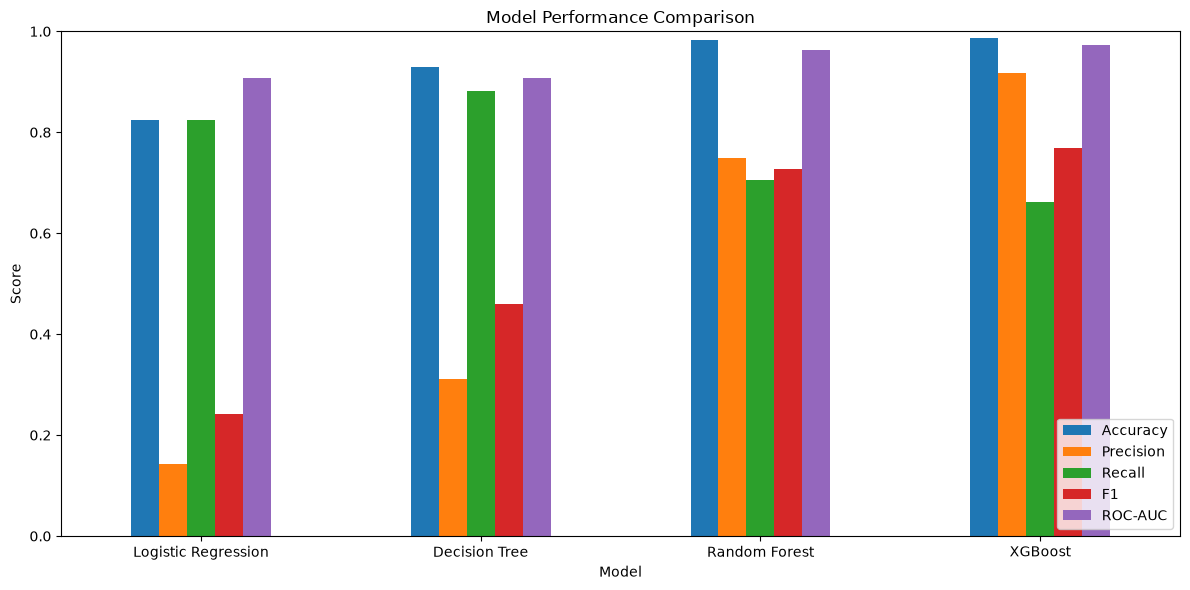

In [22]:
results_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [23]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.471545,0.852941,0.607330
1,0.15,0.580000,0.852941,0.690476
2,0.20,0.647059,0.808824,0.718954
3,0.25,0.726027,0.779412,0.751773
4,0.30,0.768116,0.779412,0.773723
5,0.35,0.772727,0.750000,0.761194
6,0.40,0.859649,0.720588,0.784000
7,0.45,0.886792,0.691176,0.776860
8,0.50,0.918367,0.661765,0.769231
9,0.55,0.930233,0.588235,0.720721


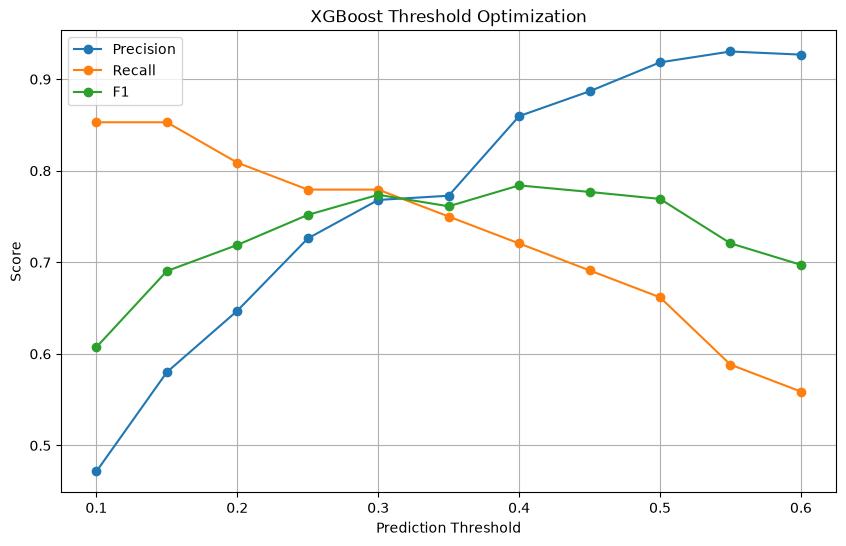

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Optimization")

plt.legend()
plt.grid(True)

plt.show()

In [25]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_threshold_row)

Threshold    0.400000
Precision    0.859649
Recall       0.720588
F1           0.784000
Name: 6, dtype: float64


In [26]:
print(y_train.value_counts())

Machine failure
0    7729
1     271
Name: count, dtype: int64


In [27]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Normal machines:", negative)
print("Failed machines:", positive)
print("Scale positive weight:", scale_pos_weight)

Normal machines: 7729
Failed machines: 271
Scale positive weight: 28.52029520295203


In [28]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [29]:
xgb_tuning = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [30]:
param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "scale_pos_weight": [1, 10, 20, 28, 30]
}

In [31]:
random_search = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [32]:
random_search.fit(
    X_train_xgb,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns t

In [33]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.7, 'scale_pos_weight': 10, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.9}


In [34]:
print("Best Cross-Validation F1:")
print(random_search.best_score_)

Best Cross-Validation F1:
0.7317963255724775


In [35]:
best_xgb = random_search.best_estimator_

In [36]:
y_pred_best = best_xgb.predict(X_test_xgb)

y_prob_best = best_xgb.predict_proba(
    X_test_xgb
)[:, 1]

In [37]:
print("Tuned XGBoost Results")
print("---------------------")

print(
    "Accuracy :",
    accuracy_score(y_test, y_pred_best)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_best)
)

print(
    "Recall   :",
    recall_score(y_test, y_pred_best)
)

print(
    "F1 Score :",
    f1_score(y_test, y_pred_best)
)

print(
    "ROC-AUC  :",
    roc_auc_score(y_test, y_prob_best)
)

Tuned XGBoost Results
---------------------
Accuracy : 0.982
Precision: 0.7105263157894737
Recall   : 0.7941176470588235
F1 Score : 0.75
ROC-AUC  : 0.9725216173425892


In [38]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.79      0.75        68

    accuracy                           0.98      2000
   macro avg       0.85      0.89      0.87      2000
weighted avg       0.98      0.98      0.98      2000



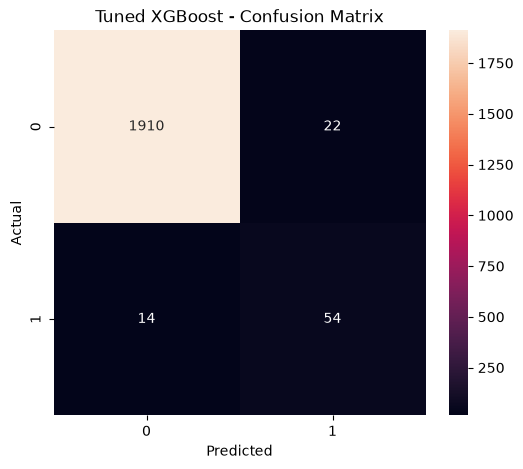

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Tuned XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Original XGBoost": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_prob_xgb)
    ],

    "Tuned XGBoost": [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best),
        roc_auc_score(y_test, y_prob_best)
    ]
})

comparison

,Metric,Original XGBoost,Tuned XGBoost
0,Accuracy,0.986500,0.982000
1,Precision,0.918367,0.710526
2,Recall,0.661765,0.794118
3,F1,0.769231,0.750000
4,ROC-AUC,0.972171,0.972522


In [41]:
y_prob_tuned = best_xgb.predict_proba(X_test_xgb)[:, 1]

In [42]:
thresholds = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_tuned >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df_tuned = pd.DataFrame(threshold_results)

threshold_df_tuned

,Threshold,Precision,Recall,F1
0,0.10,0.389937,0.911765,0.546256
1,0.15,0.413793,0.882353,0.563380
2,0.20,0.467213,0.838235,0.600000
3,0.25,0.513514,0.838235,0.636872
4,0.30,0.549020,0.823529,0.658824
5,0.35,0.589474,0.823529,0.687117
6,0.40,0.602151,0.823529,0.695652
7,0.45,0.658824,0.823529,0.732026
8,0.50,0.710526,0.794118,0.750000
9,0.55,0.750000,0.794118,0.771429


In [43]:
best_threshold = threshold_df_tuned.loc[
    threshold_df_tuned["F1"].idxmax()
]

print(best_threshold)

Threshold    0.600000
Precision    0.760563
Recall       0.794118
F1           0.776978
Name: 10, dtype: float64


In [45]:
import shap

In [46]:
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(
    X_test_xgb
)

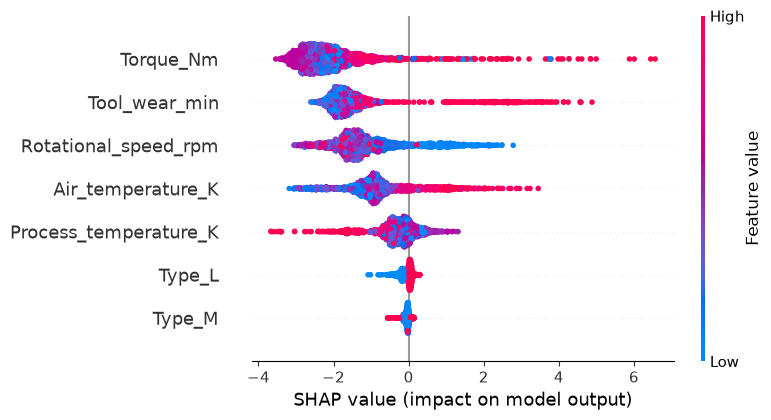

In [47]:
shap.summary_plot(
    shap_values,
    X_test_xgb
)

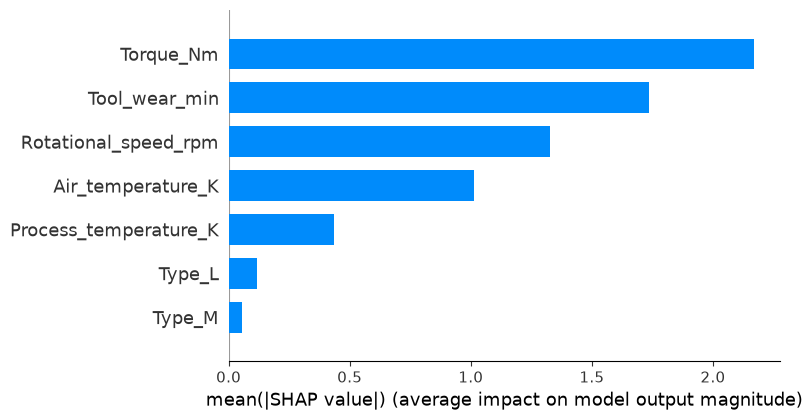

In [48]:
shap.summary_plot(
    shap_values,
    X_test_xgb,
    plot_type="bar"
)

In [50]:
best_threshold_row = threshold_df_tuned.loc[
    threshold_df_tuned["F1"].idxmax()
]

In [51]:
FINAL_THRESHOLD = float(best_threshold_row["Threshold"])

print("Final threshold:", FINAL_THRESHOLD)

Final threshold: 0.6000000000000002


In [54]:
y_prob_tuned = best_xgb.predict_proba(X_test_xgb)[:, 1]

print(y_prob_tuned[:10])

[3.8772038e-01 7.6499156e-04 1.6984323e-01 3.0163187e-03 7.9967208e-02
 1.0284758e-03 5.2844740e-02 8.4860896e-04 1.8736227e-04 8.2836241e-02]


In [55]:
import numpy as np
import pandas as pd

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_tuned >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df_tuned = pd.DataFrame(threshold_results)

threshold_df_tuned

,Threshold,Precision,Recall,F1
0,0.10,0.389937,0.911765,0.546256
1,0.15,0.413793,0.882353,0.563380
2,0.20,0.467213,0.838235,0.600000
3,0.25,0.513514,0.838235,0.636872
4,0.30,0.549020,0.823529,0.658824
5,0.35,0.589474,0.823529,0.687117
6,0.40,0.602151,0.823529,0.695652
7,0.45,0.658824,0.823529,0.732026
8,0.50,0.710526,0.794118,0.750000
9,0.55,0.750000,0.794118,0.771429


In [56]:
best_threshold_row = threshold_df_tuned.loc[
    threshold_df_tuned["F1"].idxmax()
]

print(best_threshold_row)

Threshold    0.600000
Precision    0.760563
Recall       0.794118
F1           0.776978
Name: 10, dtype: float64


In [57]:
FINAL_THRESHOLD = float(
    best_threshold_row["Threshold"]
)

print("Final threshold:", FINAL_THRESHOLD)

Final threshold: 0.6000000000000002


In [58]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_package = {
    "model": best_xgb,
    "threshold": FINAL_THRESHOLD,
    "features": X_train_xgb.columns.tolist()
}

joblib.dump(
    model_package,
    "../models/predictive_maintenance_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [59]:
loaded_package = joblib.load(
    "../models/predictive_maintenance_model.pkl"
)

print(loaded_package.keys())
print(loaded_package["threshold"])
print(loaded_package["features"])

dict_keys(['model', 'threshold', 'features'])
0.6000000000000002
['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_L', 'Type_M']


In [61]:
sample_index = 0

sample = X_test_xgb.iloc[
    [sample_index]
]

prediction_probability = best_xgb.predict_proba(
    sample
)[0, 1]

prediction = int(
    prediction_probability >= FINAL_THRESHOLD
)

print("Failure probability:", prediction_probability)
print("Prediction:", prediction)

Failure probability: 0.38772038
Prediction: 0


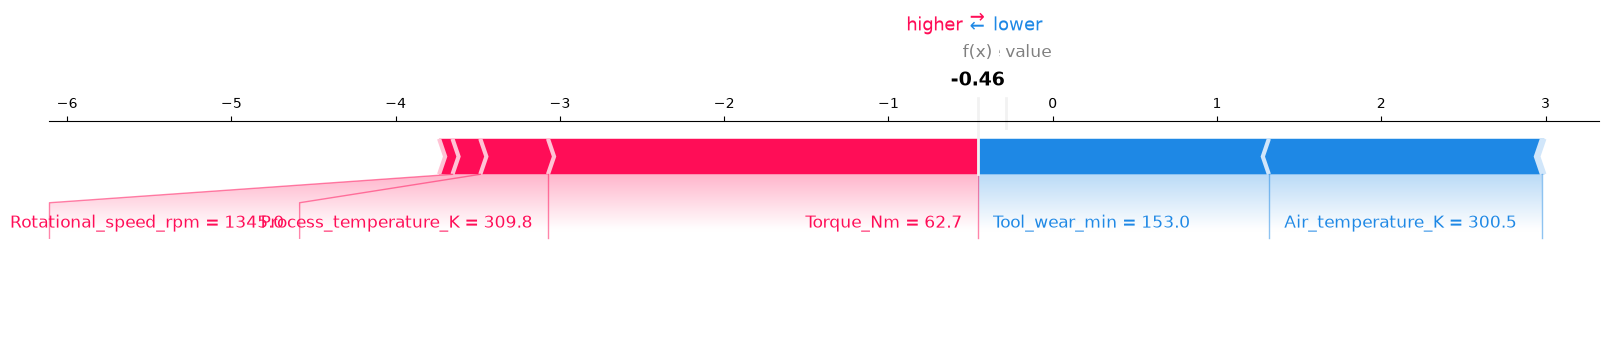

In [62]:
shap_values_sample = explainer.shap_values(
    sample
)

shap.force_plot(
    explainer.expected_value,
    shap_values_sample[0],
    sample.iloc[0],
    matplotlib=True
)

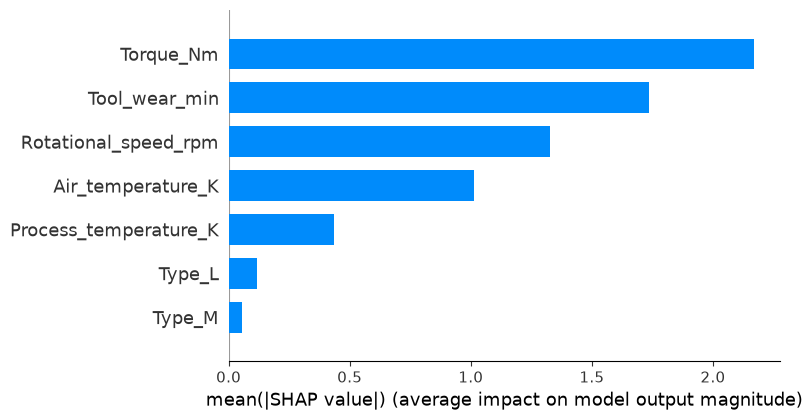

In [63]:
shap.summary_plot(
    shap_values,
    X_test_xgb,
    plot_type="bar"
)

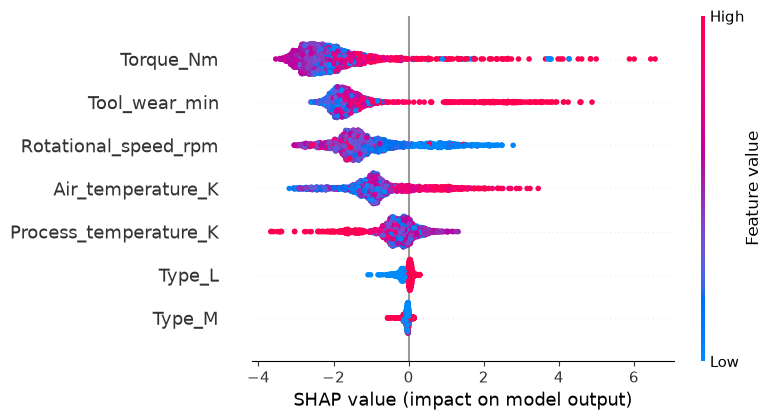

In [64]:
shap.summary_plot(
    shap_values,
    X_test_xgb
)

In [65]:
import joblib

model_package = joblib.load(
    "../models/predictive_maintenance_model.pkl"
)

print("Saved components:")
print(model_package.keys())

print("\nThreshold:")
print(model_package["threshold"])

print("\nFeatures:")
print(model_package["features"])

Saved components:
dict_keys(['model', 'threshold', 'features'])

Threshold:
0.6000000000000002

Features:
['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_L', 'Type_M']


In [67]:
print("best_xgb:", type(best_xgb))
print("X_test_xgb:", X_test_xgb.shape)
print("y_test:", y_test.shape)
print("FINAL_THRESHOLD:", FINAL_THRESHOLD)

best_xgb: <class 'xgboost.sklearn.XGBClassifier'>
X_test_xgb: (2000, 7)
y_test: (2000,)
FINAL_THRESHOLD: 0.6000000000000002


In [68]:
y_prob_tuned = best_xgb.predict_proba(
    X_test_xgb
)[:, 1]

y_pred_final = (
    y_prob_tuned >= FINAL_THRESHOLD
).astype(int)

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_final
    ),

    "Precision": precision_score(
        y_test,
        y_pred_final,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_pred_final,
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_test,
        y_pred_final,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_tuned
    )
}

final_results

{'Accuracy': 0.9845,
 'Precision': 0.7605633802816901,
 'Recall': 0.7941176470588235,
 'F1 Score': 0.7769784172661871,
 'ROC-AUC': 0.9725216173425892}

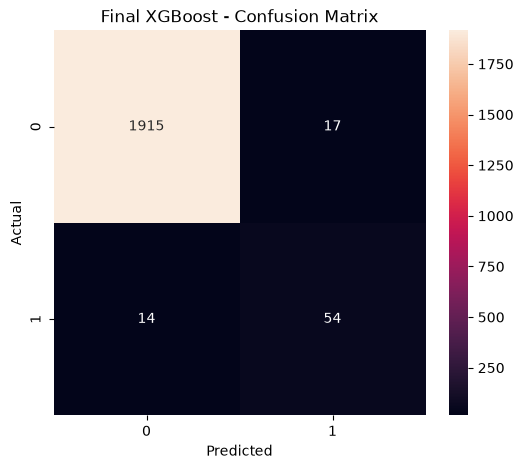

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Final XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [71]:
y_pred_final = (
    y_prob_tuned >= FINAL_THRESHOLD
).astype(int)

In [72]:
print(final_results)

{'Accuracy': 0.9845, 'Precision': 0.7605633802816901, 'Recall': 0.7941176470588235, 'F1 Score': 0.7769784172661871, 'ROC-AUC': 0.9725216173425892}


In [73]:
import joblib

model_package = joblib.load(
    "../models/predictive_maintenance_model.pkl"
)

print(model_package.keys())
print("Threshold:", model_package["threshold"])
print("Features:", model_package["features"])

dict_keys(['model', 'threshold', 'features'])
Threshold: 0.6000000000000002
Features: ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_L', 'Type_M']
